# Vuilniswagen: batterijdegradatie met en zonder ePTO (theoretisch)

Dit notebook roept de losse Python-bestanden aan. Elk bestand doet één ding:

| Bestand | Functie |
|---|---|
| `config.py` | Alle aannames (pakketgrootte, dagcyclus, laden, instellingen). **Hier pas je later echte klantdata in aan.** |
| `load_profiles.py` | Bouwt het vermogensprofiel van één werkdag, met en zonder ePTO. |
| `battery_model.py` | Het PyBaMM-celmodel met degradatie (SEI-groei, temperatuur). |
| `degradation_sim.py` | Simuleert meerdere werkdagen (rijden + nachtladen) en leest het capaciteitsverlies uit. |
| `pack_sim.py` | Liionpack: een klein stuk pakket met cellen die onderling verschillen. |
| `analysis.py` | Vergelijkingstabel en grafieken. |

**Belangrijk:** alle getallen zijn aannames, geen metingen. De uitkomst laat het *verschil tussen de scenario's* zien
en welke data we bij de klant moeten opvragen. Het is geen voorspelling van de levensduur.

## 0. Installatie (eenmalig)

PyBaMM is de rekenkern voor één cel. Liionpack bouwt daar een pakket omheen.
De versies staan vast in `requirements.txt`, omdat liionpack niet met de nieuwste PyBaMM werkt.
Draai onderstaande cel één keer en herstart daarna de kernel.

In [1]:
# %pip install -r requirements.txt

## 1. Imports en aannames

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from config import PACK, DUTY, CHARGING, DEGRADATION, PACK_SIM
from load_profiles import build_daily_power_profile, daily_energy_kwh
from degradation_sim import run_degradation
from pack_sim import select_work_window, run_pack_simulation, summarize_pack_result
from analysis import (compare_degradation, extrapolate_capacity, plot_power_profiles,
                      plot_degradation, plot_pack_currents)

print(f"Theoretisch pakket: {PACK.n_series}s x {PACK.n_parallel}p = {PACK.n_cells} cellen, "
      f"{PACK.pack_energy_kwh:.0f} kWh")

Theoretisch pakket: 216s x 52p = 11232 cellen, 202 kWh


**Snel testen of echt rekenen?**
Een PyBaMM-degradatiesimulatie is traag. Zet `SNEL_TESTEN = True` om de code te testen (paar dagen, snelle modus),
en `False` voor de echte run (ruim uur of meer, laat het bijvoorbeeld 's nachts draaien).

In [3]:
SNEL_TESTEN = True

if SNEL_TESTEN:
    N_DAGEN, MODE = 3, "snel"
else:
    N_DAGEN, MODE = DEGRADATION.n_days, DEGRADATION.mode
print(N_DAGEN, MODE)

3 snel


## 2. Vermogensprofielen van één werkdag

Beide scenario's hebben **exact dezelfde rit** (zelfde seed). Het enige verschil: bij "met ePTO" haalt de opbouw
(lift + perskast) tijdens elke stop vermogen uit de tractiebatterij. Bij "zonder ePTO" draait de opbouw op een
andere energiebron (bijv. een dieselmotor) en ziet de batterij dat verbruik niet.

Zonder ePTO: {'verbruikt_kWh': 105.24257134751623, 'regen_kWh': 2.669493277189989, 'netto_kWh': 102.57307807032623}
Met ePTO:    {'verbruikt_kWh': 140.75368245862734, 'regen_kWh': 2.669493277189989, 'netto_kWh': 138.08418918143735}


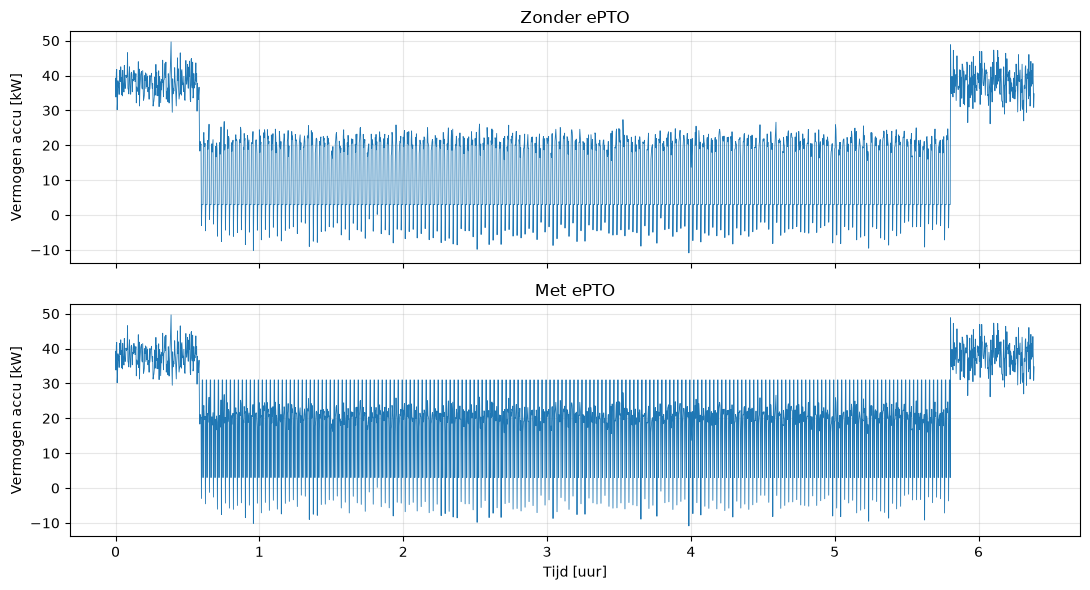

In [4]:
t0, p0 = build_daily_power_profile(DUTY, with_epto=False)
t1, p1 = build_daily_power_profile(DUTY, with_epto=True)

print("Zonder ePTO:", daily_energy_kwh(t0, p0))
print("Met ePTO:   ", daily_energy_kwh(t1, p1))

fig = plot_power_profiles({"Zonder ePTO": (t0, p0), "Met ePTO": (t1, p1)})
plt.show()

## 3. Pakketsimulatie met liionpack (1 uur inzamelroute)

Hier kijken we naar een klein stuk pakket (bijv. 8 in serie x 4 parallel). Elke cel krijgt een iets andere interne weerstand.
Zo zie je hoe ongelijk de stroom over parallelle cellen wordt verdeeld. Dat is de eerste aanwijzing waar cellen sneller verouderen.

Stepping simulation: 100%|██████████| 360/360 [00:06<00:00, 52.42it/s]


{'scenario': 'Zonder ePTO', 'max_cell_current_A': 0.6463794708251953, 'max_c_rate': 0.12927589416503907, 'rms_current_mean_A': 0.364643394947052, 'rms_current_spread_percent': 0.2476665662476803, 'min_voltage_V': 4.058963298797607}


Stepping simulation: 100%|██████████| 360/360 [00:06<00:00, 52.34it/s]


{'scenario': 'Met ePTO', 'max_cell_current_A': 0.747512698173523, 'max_c_rate': 0.14950253963470458, 'rms_current_mean_A': 0.5071932673454285, 'rms_current_spread_percent': 0.1785342633128894, 'min_voltage_V': 4.0251874923706055}


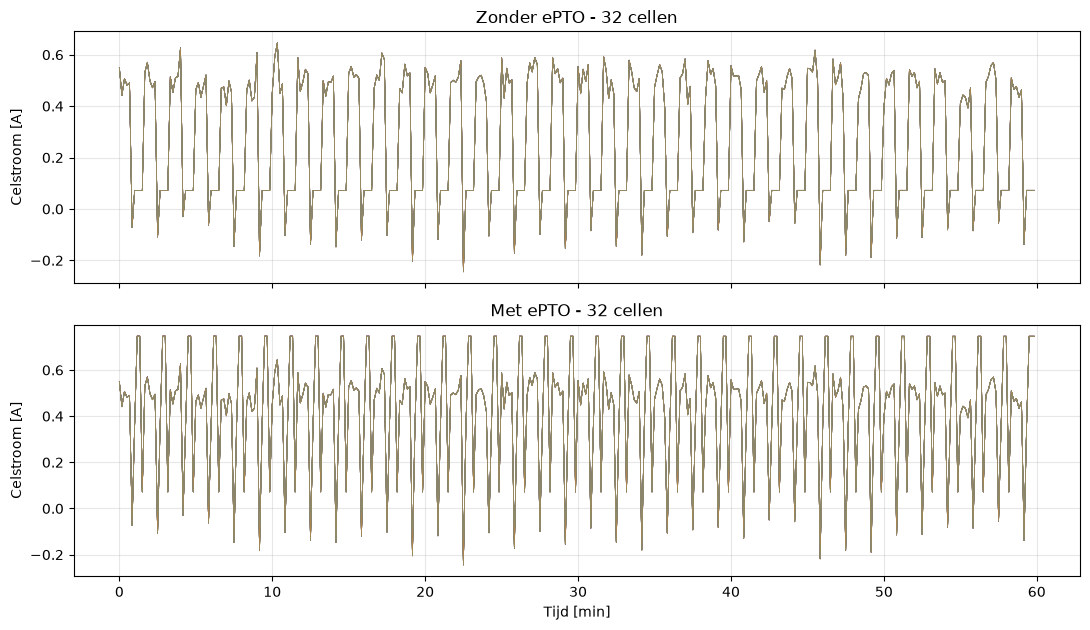

In [5]:
results_pack = []
for naam, (t, p) in {"Zonder ePTO": (t0, p0), "Met ePTO": (t1, p1)}.items():
    tw, pw = select_work_window(t, p, start_min=35, duration_min=PACK_SIM.duration_minutes)
    res = run_pack_simulation(naam, tw, pw, PACK, PACK_SIM)
    results_pack.append(res)
    print(summarize_pack_result(res))

plot_pack_currents(results_pack)
plt.show()

## 4. Degradatiesimulatie over meerdere werkdagen

Elke dag = werkdag + nachtladen (CC-CV) + rust. PyBaMM rekent de groei van de SEI-laag door en daarmee het capaciteitsverlies.
Dit is het trage deel.

In [6]:
res_zonder = run_degradation("Zonder ePTO", t0, p0, PACK, CHARGING, N_DAGEN,
                             DEGRADATION.ambient_temperature_c, DEGRADATION.parameter_set,
                             DEGRADATION.solver_dt_s, MODE)
res_met = run_degradation("Met ePTO", t1, p1, PACK, CHARGING, N_DAGEN,
                          DEGRADATION.ambient_temperature_c, DEGRADATION.parameter_set,
                          DEGRADATION.solver_dt_s, MODE)

## 5. Vergelijking

,dagen,capaciteit_start_Ah,capaciteit_eind_Ah,capaciteitsverlies_%,verlies_per_dag_%,LLI_%,doorzet_Ah_per_cel
scenario,,,,,,,
Zonder ePTO,3,5.1096,5.1091,0.0109,0.0055,0.0119,13.5177
Met ePTO,3,5.1096,5.1090,0.0121,0.0060,0.0132,18.7529


Extra capaciteitsverlies door ePTO (procentpunt): 0.00115
Relatief meer verlies met ePTO (%): 10.6


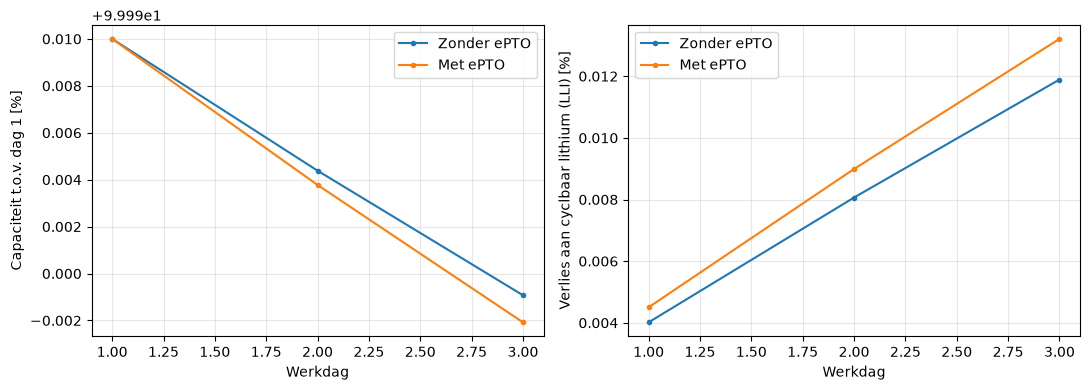

In [7]:
tabel = compare_degradation(res_zonder, res_met)
display(tabel.round(4))
print("Extra capaciteitsverlies door ePTO (procentpunt):", round(tabel.attrs["extra_verlies_door_epto_%"], 5))
print("Relatief meer verlies met ePTO (%):", round(tabel.attrs["relatief_meer_verlies_%"], 1))

plot_degradation(res_zonder, res_met)
plt.show()

### Indicatieve doorrekening naar 5 jaar

Lineaire extrapolatie van de trend (250 werkdagen per jaar). Echte veroudering is niet lineair, dus lees dit als
grove richting. Met maar een paar gesimuleerde dagen is het vooral een indicatie.

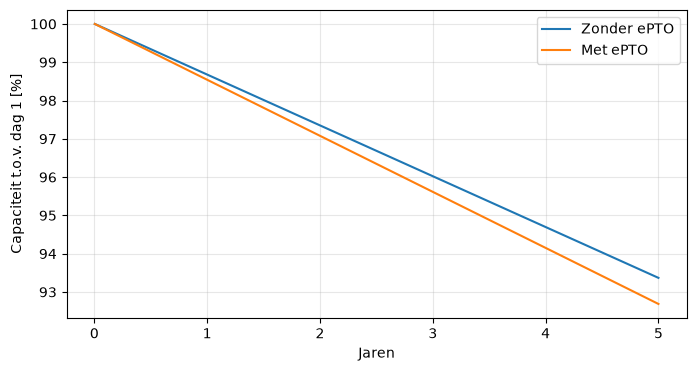

In [8]:
DAGEN_5_JAAR = 5 * 250
plt.figure(figsize=(8, 4))
for res in (res_zonder, res_met):
    d, cap = extrapolate_capacity(res, DAGEN_5_JAAR)
    plt.plot(d / 250, 100 * cap, label=res["scenario"])
plt.xlabel("Jaren"); plt.ylabel("Capaciteit t.o.v. dag 1 [%]")
plt.grid(alpha=0.3); plt.legend(); plt.show()

## 6. Wat we bij de klant willen opvragen

Vervang dan de aannames in `config.py`:
- Echte accugrootte, celtype en configuratie (serie/parallel), en de gebruikte SOC-window.
- Gelogd vermogen of stroom van de batterij (CAN/telematica), idealiter met en zonder ePTO-gebruik.
- Aantal stops per route, ePTO-vermogen per bewegingsdeel (lift, pers) en de duur ervan.
- Route-eigenschappen: transportafstand, hoogteverschillen, werkdagen per jaar.
- Laadstrategie: laadvermogen, laadtijd, laadlimiet (bijv. tot 90% of 100%).
- Omgevingstemperatuur en koelstrategie van het pakket.
- Als het kan: gemeten capaciteit of SOH na X maanden, om het model te kalibreren.